# Global Pollution Analysis


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("Global_Pollution_Analysis.csv")
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [27]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [28]:
pollution_columns = [ "Air_Pollution_Index", "Water_Pollution_Index", "Soil_Pollution_Index" ]

In [29]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
scaler = StandardScaler()
le = LabelEncoder()

In [30]:
df[pollution_columns].head(10)

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
0,272.70,124.27,51.95
1,86.72,60.34,117.22
2,91.59,83.36,121.72
3,280.61,67.16,93.58
4,179.16,127.53,121.55
5,151.36,61.07,86.75
6,292.31,156.85,36.40
7,209.41,188.14,133.50
8,269.63,62.33,71.19
9,231.99,155.31,44.99


In [31]:
df[pollution_columns] = scaler.fit_transform(df[pollution_columns])
df[pollution_columns].head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
0,1.376167,0.193880,-0.619764
1,-1.403578,-1.153098,1.028744
2,-1.330788,-0.668076,1.142400
3,1.494394,-1.009403,0.431675
4,-0.021926,0.262567,1.138106


In [32]:
df["Country"] = le.fit_transform(df["Country"])
df["Year"] = le.fit_transform(df["Year"])

In [33]:
df[["Country", "Year"]]

,Country,Year
0,77,5
1,147,1
2,136,16
3,38,18
4,46,8
...,...,...
195,92,4
196,13,2
197,88,11
198,170,2


In [34]:
yearly_data = df.groupby('Year')[ 
    ['Air_Pollution_Index',
     'Water_Pollution_Index',
     'Soil_Pollution_Index',
     'Energy_Recovered (in GWh)']
].mean()

In [35]:
yearly_data.head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
Year,,,,
0,0.256617,0.072583,-0.181989,296.889000
1,-0.637654,-0.655996,-0.130036,288.877778
2,-0.089162,0.180136,-0.028892,259.750769
3,0.335938,0.379503,0.611174,208.139000
4,-0.142082,0.119064,-0.164913,186.458182


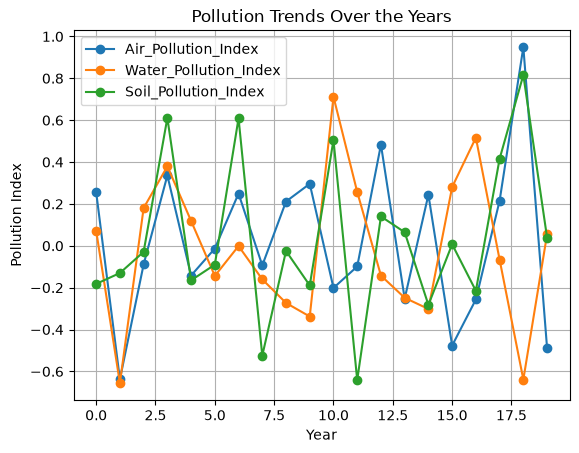

In [36]:
yearly_data[ 
    ['Air_Pollution_Index',
     'Water_Pollution_Index',
     'Soil_Pollution_Index']
].plot(kind='line', marker='o')


plt.title("Pollution Trends Over the Years")
plt.xlabel("Year") 
plt.ylabel("Pollution Index") 
plt.grid(True) 
plt.show()

<Axes: >

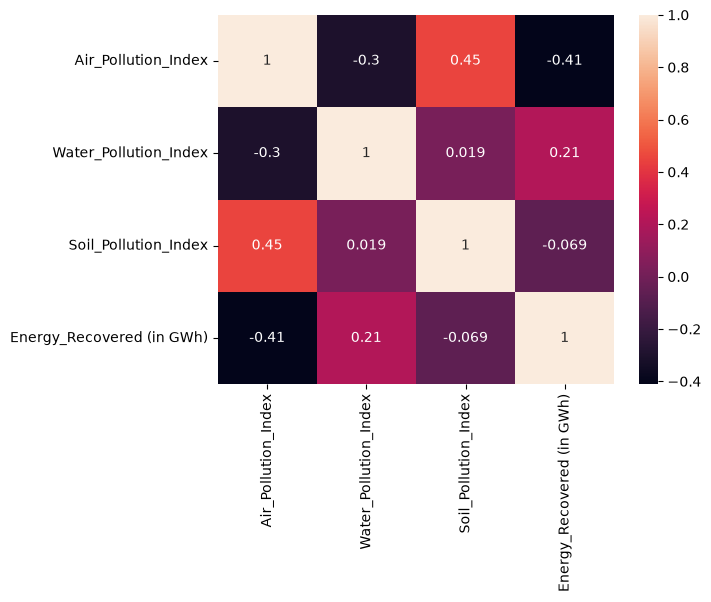

In [37]:
corr = yearly_data.corr()
sns.heatmap(corr, annot=True)

In [38]:
df["Pollution_Severity_Air"] = pd.qcut(
    df["Air_Pollution_Index"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [39]:
df["Pollution_Severity_Air"].head()

0      High
1       Low
2       Low
3      High
4    Medium
Name: Pollution_Severity_Air, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [40]:
df["Pollution_Severity_Water"] = pd.qcut(
    df["Air_Pollution_Index"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [41]:
df["Pollution_Severity_Water"].head()

0      High
1       Low
2       Low
3      High
4    Medium
Name: Pollution_Severity_Water, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [44]:
df["Energy_Consumption_Level"] = pd.qcut( 
    df["Energy_Consumption_Per_Capita (in MWh)"],
    q=3,
    labels=["Low", "Medium", "High"] 
)

In [45]:
df["Energy_Consumption_Level"].head()

0    High
1     Low
2    High
3     Low
4    High
Name: Energy_Consumption_Level, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [46]:
df["Energy_Recovery_Level"] = pd.qcut( 
    df["Energy_Recovered (in GWh)"], 
    q=3, 
    labels=["Low", "Medium", "High"] 
)

In [47]:
df["Energy_Recovery_Level"].head()

0     Low
1    High
2    High
3     Low
4     Low
Name: Energy_Recovery_Level, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [43]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [48]:
df[ 
    [ "Country", 
     "Pollution_Severity_Air", 
     "Pollution_Severity_Water", 
     "Energy_Consumption_Level", 
     "Energy_Recovery_Level" ] ].head()

,Country,Pollution_Severity_Air,Pollution_Severity_Water,Energy_Consumption_Level,Energy_Recovery_Level
0,77,High,High,High,Low
1,147,Low,Low,Low,High
2,136,Low,Low,High,High
3,38,High,High,Low,Low
4,46,Medium,Medium,High,Low


In [52]:
transactions = []
for index, row in df.iterrows():
    transaction = [ 
        "Air_" + str(row["Pollution_Severity_Air"]),
        "Water_" + str(row["Pollution_Severity_Water"]), 
        "EnergyConsumption_" + str(row["Energy_Consumption_Level"]), 
        "EnergyRecovery_" + str(row["Energy_Recovery_Level"]) ] 

    transactions.append(transaction)

In [53]:
Tencoeder = TransactionEncoder()

encoded_data = Tencoeder.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(
    encoded_data,
    columns=Tencoeder.columns_
)

In [56]:
transaction_df.head()

,Air_High,Air_Low,Air_Medium,EnergyConsumption_High,EnergyConsumption_Low,EnergyConsumption_Medium,EnergyRecovery_High,EnergyRecovery_Low,EnergyRecovery_Medium,Water_High,Water_Low,Water_Medium
0,True,False,False,True,False,False,False,True,False,True,False,False
1,False,True,False,False,True,False,True,False,False,False,True,False
2,False,True,False,True,False,False,True,False,False,False,True,False
3,True,False,False,False,True,False,False,True,False,True,False,False
4,False,False,True,True,False,False,False,True,False,False,False,True


In [65]:
train_data = transaction_df.sample(
    frac=0.80,
    random_state=42
)

test_data = transaction_df.drop(train_data.index)

In [66]:
train_data.shape

(160, 12)

In [67]:
test_data.shape

(40, 12)

In [68]:
frequent = apriori(
    train_data,
    min_support=0.20,
    use_colnames=True
)

frequent

,support,itemsets
0,0.31875,frozenset({Air_High})
1,0.33750,frozenset({Air_Low})
2,0.34375,frozenset({Air_Medium})
3,0.34375,frozenset({EnergyConsumption_High})
4,0.33750,frozenset({EnergyConsumption_Low})
5,0.31875,frozenset({EnergyConsumption_Medium})
6,0.34375,frozenset({EnergyRecovery_High})
7,0.33750,frozenset({EnergyRecovery_Low})
8,0.31875,frozenset({EnergyRecovery_Medium})
9,0.31875,frozenset({Water_High})


In [70]:
rules = association_rules(
    frequent,
    metric="confidence",
    min_threshold=0.50
)

rules = rules[
    [
        "antecedents", 
        "consequents", 
        "support", 
        "confidence", 
        "lift"
    ]
]

rules = rules.sort_values(
    by='lift',
    ascending=False
)

rules

,antecedents,consequents,support,confidence,lift
0,frozenset({Water_High}),frozenset({Air_High}),0.31875,1.0,3.137255
1,frozenset({Air_High}),frozenset({Water_High}),0.31875,1.0,3.137255
2,frozenset({Air_Low}),frozenset({Water_Low}),0.33750,1.0,2.962963
3,frozenset({Water_Low}),frozenset({Air_Low}),0.33750,1.0,2.962963
4,frozenset({Water_Medium}),frozenset({Air_Medium}),0.34375,1.0,2.909091
5,frozenset({Air_Medium}),frozenset({Water_Medium}),0.34375,1.0,2.909091


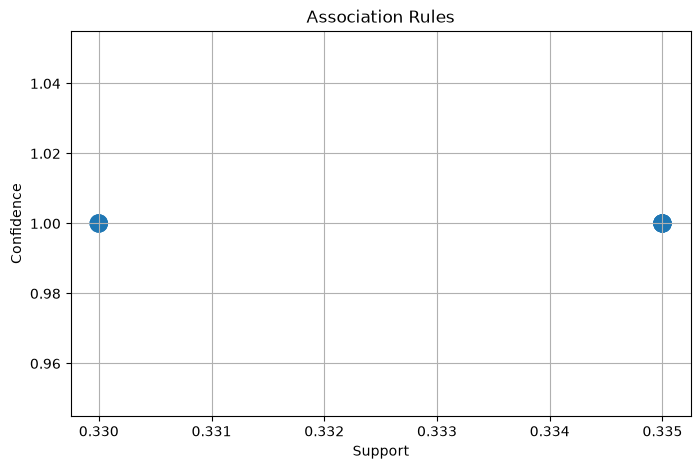

In [60]:
plt.figure(figsize=(8, 5)) 
plt.scatter( 
    rules["support"], 
    rules["confidence"], 
    s=rules["lift"] * 50 )

 
plt.xlabel("Support") 
plt.ylabel("Confidence") 
plt.title("Association Rules") 
plt.grid(True) 
plt.show()

In [71]:
def test_rule_accuracy(rules, test_data):
    
    results = []
    
    for index, rule in rules.iterrows():
        
        antecedent = list(rule["antecedents"])
        consequent = list(rule["consequents"])
        
        antecedent_rows = test_data[
            test_data[antecedent].all(axis=1)
        ]
        
        if len(antecedent_rows) > 0:
            
            correct_rows = antecedent_rows[
                antecedent_rows[consequent].all(axis=1)
            ]
            
            accuracy = len(correct_rows) / len(antecedent_rows)
            
            results.append({
                "antecedents": rule["antecedents"],
                "consequents": rule["consequents"],
                "accuracy": accuracy,
                "confidence": rule["confidence"],
                "lift": rule["lift"]
            })
    
    return pd.DataFrame(results)

In [72]:
test_results = test_rule_accuracy(rules, test_data)

test_results = test_results.sort_values(
    by="accuracy",
    ascending=False
)

test_results.head(10)

,antecedents,consequents,accuracy,confidence,lift
0,frozenset({Water_High}),frozenset({Air_High}),1.0,1.0,3.137255
1,frozenset({Air_High}),frozenset({Water_High}),1.0,1.0,3.137255
2,frozenset({Air_Low}),frozenset({Water_Low}),1.0,1.0,2.962963
3,frozenset({Water_Low}),frozenset({Air_Low}),1.0,1.0,2.962963
4,frozenset({Water_Medium}),frozenset({Air_Medium}),1.0,1.0,2.909091
5,frozenset({Air_Medium}),frozenset({Water_Medium}),1.0,1.0,2.909091


In [73]:
if len(test_results) > 0:
    average_accuracy = test_results["accuracy"].mean()
    print("Average rule accuracy on test data:",
          round(average_accuracy, 3))
else:
    print("No rules could be tested on the test data.")

Average rule accuracy on test data: 1.0


In [75]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [76]:
cv_results = []

fold_number = 1

for train_index, test_index in kf.split(transaction_df):
    
    train = transaction_df.iloc[train_index]
    test = transaction_df.iloc[test_index]
    
    # Find frequent itemsets
    frequent = apriori(
        train,
        min_support=0.10,
        use_colnames=True
    )
    
    if len(frequent) == 0:
        continue
    
    # Generate rules
    fold_rules = association_rules(
        frequent,
        metric="confidence",
        min_threshold=0.50
    )
    
    if len(fold_rules) == 0:
        continue
    
    # Test the rules
    fold_test_results = test_rule_accuracy(
        fold_rules,
        test
    )
    
    if len(fold_test_results) > 0:
        
        cv_results.append({
            "Fold": fold_number,
            "Number of Rules": len(fold_rules),
            "Average Accuracy": fold_test_results["accuracy"].mean(),
            "Average Confidence": fold_rules["confidence"].mean(),
            "Average Lift": fold_rules["lift"].mean()
        })
    
    fold_number += 1

cv_results = pd.DataFrame(cv_results)

cv_results

,Fold,Number of Rules,Average Accuracy,Average Confidence,Average Lift
0,1,32,1.0,1.0,2.976127
1,2,40,1.0,1.0,3.006254
2,3,36,1.0,1.0,3.000233
3,4,36,1.0,1.0,2.986796
4,5,36,1.0,1.0,2.993420


In [77]:
if len(cv_results) > 0:
    
    print("Cross-validation results")
    print("------------------------")
    
    print(
        "Average Accuracy:",
        round(cv_results["Average Accuracy"].mean(), 3)
    )
    
    print(
        "Average Confidence:",
        round(cv_results["Average Confidence"].mean(), 3)
    )
    
    print(
        "Average Lift:",
        round(cv_results["Average Lift"].mean(), 3)
    )

Cross-validation results
------------------------
Average Accuracy: 1.0
Average Confidence: 1.0
Average Lift: 2.993


In [80]:
support_analysis = frequent.sort_values(
    by="support",
    ascending=False
)
support_analysis.head(20)

,support,itemsets
2,0.34375,frozenset({Air_Medium})
6,0.34375,frozenset({EnergyRecovery_High})
3,0.34375,frozenset({EnergyConsumption_High})
11,0.34375,frozenset({Water_Medium})
29,0.34375,"frozenset({Water_Medium, Air_Medium})"
10,0.33750,frozenset({Water_Low})
1,0.33750,frozenset({Air_Low})
23,0.33750,"frozenset({Air_Low, Water_Low})"
7,0.33750,frozenset({EnergyRecovery_Low})
4,0.33750,frozenset({EnergyConsumption_Low})


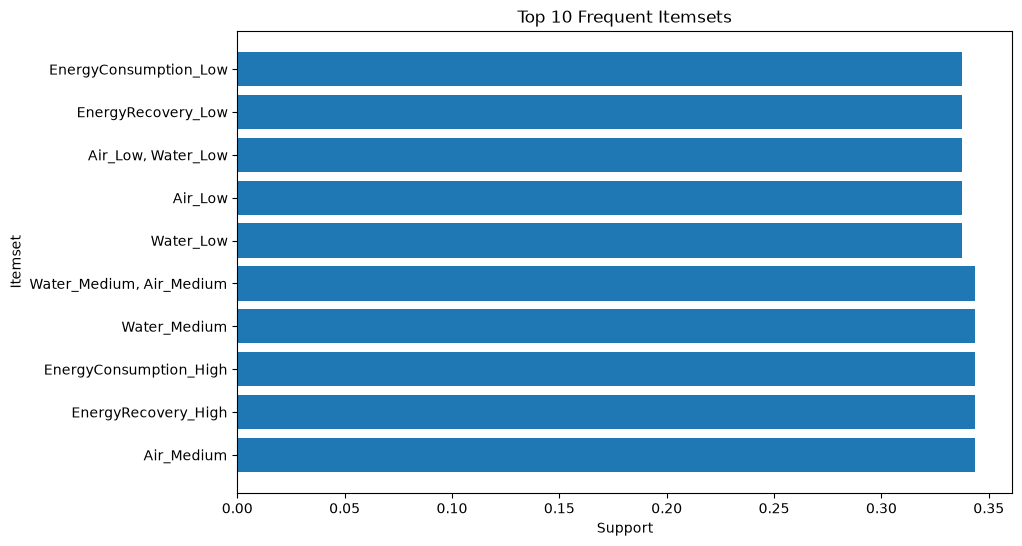

In [82]:
top_support = support_analysis.head(10).copy()

top_support["itemset"] = top_support["itemsets"].apply(
    lambda x: ", ".join(list(x))
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_support["itemset"],
    top_support["support"]
)

plt.xlabel("Support")
plt.ylabel("Itemset")
plt.title("Top 10 Frequent Itemsets")

plt.show()

In [83]:
strong_rules = rules[
    (rules["confidence"] >= 0.50) &
    (rules["lift"] > 1)
].copy()

strong_rules = strong_rules.sort_values(
    by="lift",
    ascending=False
)

print("Strong Association Rules:")
strong_rules.head(15)

Strong Association Rules:


,antecedents,consequents,support,confidence,lift
0,frozenset({Water_High}),frozenset({Air_High}),0.31875,1.0,3.137255
1,frozenset({Air_High}),frozenset({Water_High}),0.31875,1.0,3.137255
2,frozenset({Air_Low}),frozenset({Water_Low}),0.33750,1.0,2.962963
3,frozenset({Water_Low}),frozenset({Air_Low}),0.33750,1.0,2.962963
4,frozenset({Water_Medium}),frozenset({Air_Medium}),0.34375,1.0,2.909091
5,frozenset({Air_Medium}),frozenset({Water_Medium}),0.34375,1.0,2.909091


In [84]:
print("Average Confidence:",
      round(rules["confidence"].mean(), 3))

print("Average Lift:",
      round(rules["lift"].mean(), 3))

print("Maximum Lift:",
      round(rules["lift"].max(), 3))

print("Maximum Confidence:",
      round(rules["confidence"].max(), 3))

Average Confidence: 1.0
Average Lift: 3.003
Maximum Lift: 3.137
Maximum Confidence: 1.0


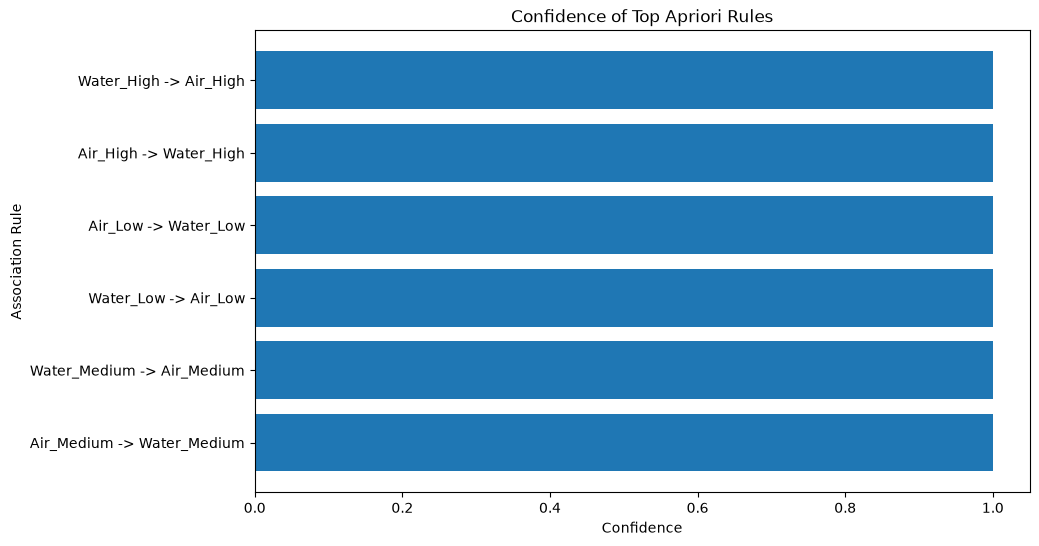

In [85]:
top_rules = rules.head(10).copy()

top_rules["rule"] = top_rules.apply(
    lambda row:
    ", ".join(list(row["antecedents"])) +
    " -> " +
    ", ".join(list(row["consequents"])),
    axis=1
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rules["rule"],
    top_rules["confidence"]
)

plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.title("Confidence of Top Apriori Rules")

plt.gca().invert_yaxis()
plt.show()